In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "6"

In [2]:
from pathlib import Path
from functools import partial

import datasets as hfds
import torch
import numpy as np
import pandas as pd
from torch.utils import flop_counter
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt

import flat_mae.transforms as flat_transforms
import flat_mae.data as flat_data
import flat_mae.models_mae as models_mae
import flat_mae.masking as flat_masking

/admin/home/connor/fmri-fm/.venv/lib/python3.11/site-packages/neuromaps/datasets/utils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [3]:
torch.backends.cudnn.benchmark = True

In [4]:
plt.style.use("../clane.mplstyle")
PLOTW = 3.25  # 6.75 two column width, 0.25 pad
plt.rcParams["figure.dpi"] = 300

In [5]:
# get some data
# just for computing training flops per batch
# note, hardcoded params from the config
dataset_root = "s3://medarc/fmri-datasets/eval"
space = "flat"
img_size = (224, 560)
patch_size = 16
t_patch_size = 4
masking = "tube"
mask_ratio = 0.9
batch_size = 32

transform = flat_transforms.make_transform(space)
dataset = hfds.load_dataset(
    "arrow",
    data_files=f"{dataset_root}/hcpya-clips.{space}.arrow/test/*.arrow",
    split="train",
)
dataset = flat_data.HFDataset(dataset, transform)
mask_fn = flat_masking.create_masking(
    name=masking,
    mask_ratio=mask_ratio,
    img_size=img_size,
    patch_size=patch_size,
    t_patch_size=t_patch_size,
)
collate_fn = partial(flat_masking.mask_collate, mask_fn=mask_fn)
loader = DataLoader(
    dataset,
    batch_size=batch_size,
    collate_fn=collate_fn,
    shuffle=False,
    num_workers=8,
    drop_last=False,
)

Resolving data files:   0%|          | 0/30 [00:00<?, ?it/s]

In [6]:
device = torch.device("cuda")

In [7]:
depths = [3, 6, 9, 12, 15]
models = {}

for depth in depths:
    ckpt_path = f"output/model_scaling/d{depth}/pretrain/checkpoint-last.pth"
    models[depth] = models_mae.MaskedAutoencoderViT.from_checkpoint(ckpt_path).to(device)

In [11]:
# fwd+bwd flops per step on a single batch
batch = next(iter(loader))
bold = batch["bold"].to(device)
mask = batch["mask"].to(device)
visible_mask = batch["visible_mask"].to(device)

flops = {}
for depth in depths:
    model = models[depth]
    counter = flop_counter.FlopCounterMode(display=False)
    with counter:
        loss = model(
            bold, img_mask=mask, visible_mask=visible_mask, mask_ratio=mask_ratio, with_state=False
        )
        loss.backward()
    flops[depth] = float(counter.get_total_flops())
    print(f"d{depth} {flops[depth] / 1e9:.0f}G")

d3 302G
d6 1493G
d9 4199G
d12 9044G
d15 16655G


In [12]:
num_params = {}
for depth in depths:
    num_params[depth] = num = sum(p.numel() for p in models[depth].parameters())
    print(f"d{depth} {num / 1e6:.0f}M")

d3 2M
d6 13M
d9 43M
d12 100M
d15 193M


In [ ]:
# load the full training logs for each run
tables = []
for depth in depths:
    log_path = f"output/model_scaling/d{depth}/pretrain/log.json"
    table = pd.read_json(log_path, lines=True)
    assert len(table) == 100, f"incomplete run {depth}"
    table.insert(0, "depth", depth)
    tables.append(table)

train_logs = pd.concat(tables, ignore_index=True)
print(train_logs.shape)
train_logs.head()

(500, 8)


,depth,epoch,train/lr,train/grad,train/loss,eval/hcp-train-subset/loss,eval/hcp-val/loss,eval/nsd-val/loss
0,3,0,0.000013,0.028102,0.995238,0.993662,0.993595,0.992893
1,3,1,0.000038,0.156348,0.990996,0.988904,0.987908,0.986133
2,3,2,0.000063,0.273202,0.982968,0.975894,0.976668,0.969183
3,3,3,0.000088,0.328873,0.963467,0.948390,0.948122,0.928609
4,3,4,0.000113,0.307492,0.939236,0.928840,0.927448,0.897169


In [14]:
# get the best epoch and loss for both hcp and nsd
# note we find the best epoch for each dataset separately, since they need not be the same
records = []
for depth, group in train_logs.groupby("depth"):
    hcp_idx = group["eval/hcp-val/loss"].argmin()
    hcp_loss = group.iloc[hcp_idx]["eval/hcp-val/loss"]
    nsd_idx = group["eval/nsd-val/loss"].argmin()
    nsd_loss = group.iloc[nsd_idx]["eval/nsd-val/loss"]
    record = {
        "depth": depth,
        "hcp_epoch": hcp_idx,
        "nsd_epoch": nsd_idx,
        "hcp_loss": hcp_loss,
        "nsd_loss": nsd_loss,
    }
    records.append(record)
best_losses = pd.DataFrame.from_records(records)
best_losses = best_losses.set_index("depth")
best_losses

,hcp_epoch,nsd_epoch,hcp_loss,nsd_loss
depth,,,,
3,93,94,0.855438,0.824220
6,98,92,0.833801,0.811278
9,95,53,0.827967,0.807045
12,99,58,0.827427,0.808666
15,98,60,0.826918,0.808894


In [14]:
prop_cycle = plt.rcParams["axes.prop_cycle"]
colors = prop_cycle.by_key()["color"]
print(colors)

['#0C5DA5', '#00B945', '#FF9500', '#FF2C00', '#845B97', '#474747', '#9e9e9e']


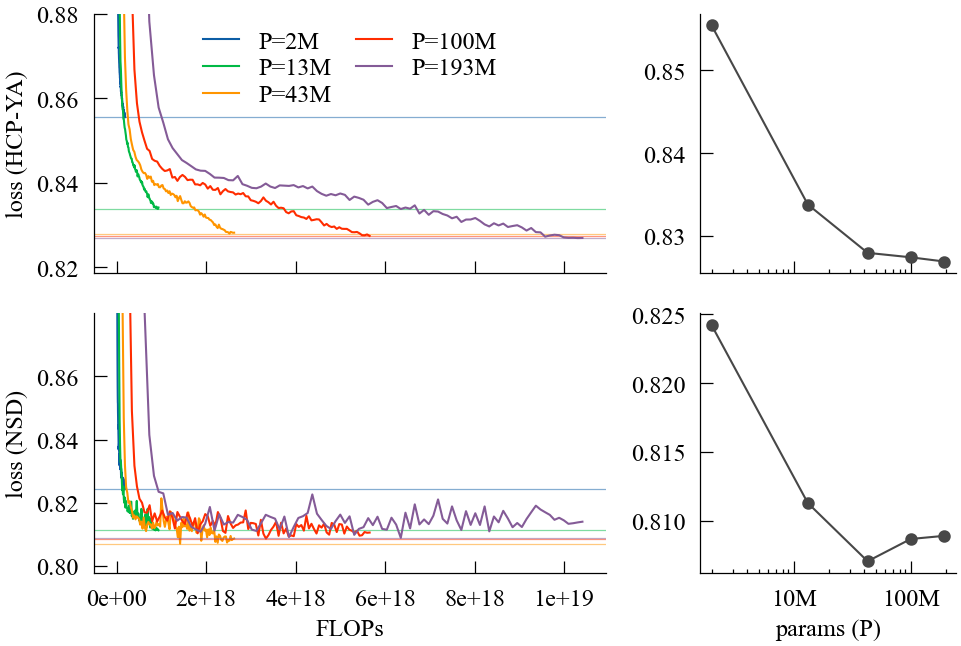

In [16]:
# 2 x 2 plot
# left col: test loss curves (aspect 2)
# right col: best loss as a function of params

f = plt.figure(figsize=(PLOTW, 2.2), constrained_layout=True)
gs = f.add_gridspec(2, 3)

ax1 = f.add_subplot(gs[0, :2])
ax2 = f.add_subplot(gs[1, :2], sharex=ax1)
ax3 = f.add_subplot(gs[0, 2])
ax4 = f.add_subplot(gs[1, 2], sharex=ax3)

# plot test loss with x axis in flops
x_steps = np.arange(1, 101) * 6250

for ii, (depth, group) in enumerate(train_logs.groupby("depth")):
    x_flops = flops[depth] * x_steps
    ax1.plot(
        x_flops,
        group["eval/hcp-val/loss"],
        lw=0.5,
        color=colors[ii],
        label=f"P={num_params[depth] / 1e6:.0f}M",
    )
    ax1.axhline(group["eval/hcp-val/loss"].min(), color=colors[ii], lw=0.3, alpha=0.5)
    ax2.plot(
        x_flops,
        group["eval/nsd-val/loss"],
        lw=0.5,
        color=colors[ii],
    )
    ax2.axhline(group["eval/nsd-val/loss"].min(), color=colors[ii], lw=0.3, alpha=0.5)

ax1.tick_params("x", labelbottom=False)
ax2.xaxis.set_major_formatter(lambda x, pos: f"{x:.0e}")
ax1.set_ylabel("loss (HCP-YA)", fontsize="small")
ax2.set_ylabel("loss (NSD)", fontsize="small")
ax2.set_xlabel("FLOPs", fontsize="small")
ax1.set_ylim(None, 0.88)
ax2.set_ylim(None, 0.88)
ax2.set_yticks([0.8, 0.82, 0.84, 0.86])
# ax1.legend(loc="upper right", ncol=1, fontsize="small")
ax1.legend(loc="upper center", ncol=2, fontsize="small")

# plot best loss as a function of params
x = np.array([num_params[depth] for depth in depths])

y = best_losses["hcp_loss"]
ax3.plot(x, y, "o-", ms=2, color=colors[-2])
ax3.tick_params("x", labelbottom=False)

y = best_losses["nsd_loss"]
ax4.plot(x, y, "o-", ms=2, color=colors[-2])

ax3.set_xscale("log")
ax4.xaxis.set_major_formatter(lambda x, pos: f"{x / 1e6:.0f}M")
ax4.set_xlabel("params (P)", fontsize="small")

f.savefig("results/model_scaling.pdf")

In [8]:
# downstream analysis
replace_d12 = True

tables = []
for depth in depths:
    if depth == 12 and replace_d12:
        out_dir = Path("../input_space/output/input_space/flat")
    else:
        out_dir = Path(f"output/model_scaling/d{depth}")
    paths = sorted(out_dir.rglob("eval_table.csv"))
    table = pd.concat((pd.read_csv(p) for p in paths), ignore_index=True)
    table.insert(0, "depth", depth)
    tables.append(table)
table = pd.concat(tables, ignore_index=True)
print(table.shape)
table.head()

(155, 16)


,depth,model,repr,clf,dataset,epoch,lr,wd,hparam_id,hparam,split,loss,acc,acc_std,f1,f1_std
0,3,flat_mae,patch,attn,aabc_age,3,0.03,0.0015,42,"[30.0, 0.03]",train,0.718521,0.712088,0.020798,0.713078,0.020783
1,3,flat_mae,patch,attn,aabc_age,3,0.03,0.0015,42,"[30.0, 0.03]",validation,2.053876,0.415094,0.067722,0.425904,0.067355
2,3,flat_mae,patch,attn,aabc_age,3,0.03,0.0015,42,"[30.0, 0.03]",test,2.030652,0.288462,0.061584,0.286478,0.062785
3,3,flat_mae,patch,attn,aabc_sex,0,0.01,0.0050,36,"[10.0, 0.1]",train,0.450321,0.794055,0.018164,0.783068,0.019870
4,3,flat_mae,patch,attn,aabc_sex,0,0.01,0.0050,36,"[10.0, 0.1]",validation,0.443389,0.844828,0.048469,0.836620,0.050913


In [9]:
summary = table.loc[table["split"] == "test"].pivot_table(
    values=["acc", "acc_std"], index=["depth", "repr", "clf"], columns="dataset"
)
summary = summary.loc[(slice(None), "patch", "attn"), :]
summary

acc                                              \
dataset           aabc_age  aabc_sex hcpya_rest1lr_gender hcpya_task21   
depth repr  clf                                                          
3     patch attn  0.288462  0.854545             0.730769     0.964881   
6     patch attn  0.365385  0.890909             0.769231     0.977579   
9     patch attn  0.461538  0.872727             0.836538     0.987103   
12    patch attn  0.365385  0.890909             0.894231     0.988690   
15    patch attn  0.423077  0.927273             0.798077     0.990873   

                                acc_std                                 \
dataset          nsd_cococlip  aabc_age  aabc_sex hcpya_rest1lr_gender   
depth repr  clf                                                          
3     patch attn     0.277922  0.061584  0.048854             0.039782   
6     patch attn     0.283673  0.066888  0.043566             0.040620   
9     patch attn     0.294620  0.064621  0.041872             0.035032   
12    patch attn     0.303340  0.065701  0.043995             0.029495   
15    patch attn     0.313544  0.058637  0.035470             0.038841   

                                            
dataset          hcpya_task21 nsd_cococlip  
depth repr  clf                             
3     patch attn     0.002660     0.005160  
6     patch attn     0.002016     0.005382  
9     patch attn     0.001564     0.005403  
12    patch attn     0.001454     0.005370  
15    patch attn     0.001327     0.005714

In [10]:
DATASET_NAMES = {
    "abide_dx": "ABIDE Dx",
    "abide_age": "ABIDE Age",
    "abide_sex": "ABIDE Sex",
    "adhd200_dx": "ADHD200 Dx",
    "adhd200_sex": "ADHD200 Sex",
    "adni_ad_vs_cn": "ADNI Dx",
    "adni_sex": "ADNI Sex",
    "ppmi_dx": "PPMI Dx",
    "ppmi_sex": "PPMI Sex",
    "ppmi_age": "PPMI Age",
    "hcpya_rest1lr_gender": "HCP-YA Sex",
    "hcpya_rest1lr_age": "HCP-YA Age",
    "hcpya_rest1lr_neofacn": "HCP-YA NEO-N",
    "aabc_sex": "HCP-A Sex",
    "aabc_age": "HCP-A Age",
    "hcpya_task21": "HCP-YA Task21",
    "nsd_cococlip": "NSD COCO24",
}

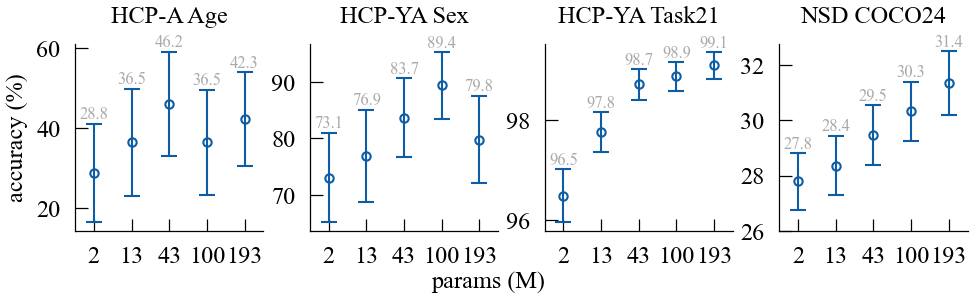

In [19]:
# datasets = ["aabc_sex", "hcpya_rest1lr_gender", "hcpya_task21", "nsd_cococlip"]
datasets = ["aabc_age", "hcpya_rest1lr_gender", "hcpya_task21", "nsd_cococlip"]

f, axs = plt.subplots(1, len(datasets), figsize=(PLOTW, 1.0))

ticklabels = [f"{par / 1e6:.0f}" for par in num_params.values()]
for ii, ds in enumerate(datasets):
    ax = axs[ii]
    plt.sca(ax)
    for jj, depth in enumerate(depths):
        subdf = summary.loc[depth]
        score = 100 * subdf.loc[:, ("acc", ds)].values[0]
        std = 100 * subdf.loc[:, ("acc_std", ds)].values[0]
        ax.errorbar(
            [jj],
            [score],
            yerr=[2 * std],
            color=colors[0],
            elinewidth=0.5,
            capsize=2.0,
            capthick=0.5,
        )
        ax.plot([jj], [score], "o", color=colors[0], ms=2, mfc="none", mew=0.5)
        ax.text(
            jj,
            score + 1.02 * 2 * std,
            f"{score:.1f}",
            fontsize=4,
            color="darkgray",
            ha="center",
            va="bottom",
        )

    ax.set_title(DATASET_NAMES[ds], fontsize="small", pad=5)
    if ii == 0:
        ax.set_ylabel("accuracy (%)", fontsize="small")

    ax.set_xticks(np.arange(len(depths)), ticklabels)
    ax.set_xlim(-0.5, len(depths) - 0.5)
    if ds == "nsd_cococlip":
        ax.set_yticks([26, 28, 30, 32])

plt.tight_layout(pad=0.2)

f.subplots_adjust(bottom=0.23)
f.text(0.5, 0.04, "params (M)", ha="center", fontsize="small")
f.savefig("results/model_scaling_downstream.pdf")